<a href="https://colab.research.google.com/github/Jules-Vatel/SSI_SPRING/blob/main/SSI_SPRING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
!pip install factor_analyzer

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer
url = "https://raw.githubusercontent.com/Jules-Vatel/SSI_SPRING/refs/heads/main/Offer-Westort_April%2028%2C%202026_08.08.csv"
df = pd.read_csv(url)


### Data Loading and Initial Setup
This section imports necessary libraries and loads the dataset from a specified URL into a pandas DataFrame. It also includes the setup for `FactorAnalyzer`, which is used later for dimensional reduction.

In [ ]:
#function for seven point party strength
def seven_pt_pid(row):
  """
  Categorizes respondents' party affiliation into a 7-point scale.

  The scale ranges from 1 (strong Democrat) to 7 (strong Republican),
  based on self-reported party and strength of affiliation. Independents
  are categorized based on their leaning.

  Args:
    row (pd.Series): A row from the DataFrame containing 'Q-PartyAffiliation',
                     'Q-PolarAffiliation', and 'Q-MiddleAffiliation'.

  Returns:
    int: An integer representing the 7-point party identification score,
         or np.nan if affiliation cannot be determined.
  """
  party = row['Q-PartyAffiliation']
  strength = row['Q-PolarAffiliation']
  lean = row['Q-MiddleAffiliation']
  # from 1 = strong democrat to 7 = strong republican
  if (party=='Democrat'):
      return 1 if strength == 'Strong' else 2
  elif(party=='Republican'):
      return 7 if strength == 'Strong' else 6
  elif(party in ['Independent','No Preference','Other Party (Please Specify)']):
      if (lean=='Closer to Democratic Party'):
          return 3
      elif (lean=='Closer to Republican Party'):
          return 5
      elif(lean=='Neither'):
          return 4
  return np.nan


### `seven_pt_pid` Function
This function categorizes respondents' party affiliation into a 7-point scale, ranging from strong Democrat (1) to strong Republican (7), based on their self-reported party and strength of affiliation. Independents are categorized based on their leaning.

In [ ]:
# function that just gets party id for leaners too
def get_party(row):
    """
    Assigns a simplified party identity ('Democrat' or 'Republican') to respondents.

    This includes individuals who identify as Independent but lean towards a party.

    Args:
      row (pd.Series): A row from the DataFrame containing 'Q-PartyAffiliation'
                       and 'Q-MiddleAffiliation'.

    Returns:
      str: 'Democrat', 'Republican', or np.nan if no clear party can be determined.
    """
    pa = row['Q-PartyAffiliation']
    if(pa=='Democrat'):
        return 'Democrat'
    elif(pa=='Republican'):
        return 'Republican'
    elif(pa in ['Independent','No Preference','Other Party (Please Specify)']):
        ma = row.get('Q-MiddleAffiliation', np.nan)
        if(ma=='Closer to Democratic Party'):
            return 'Democrat'
        elif(ma=='Closer to Republican Party'):
            return 'Republican'
    return np.nan



### `get_party` Function
This helper function simplifies party identification, assigning respondents to 'Democrat' or 'Republican' directly, including those who lean towards a party as Independents.

In [ ]:
def get_party_group(row):
    """
    Groups respondents into broader party categories: 'Democrat', 'Republican', or 'Independent'.

    Args:
      row (pd.Series): A row from the DataFrame containing 'Q-PartyAffiliation'.

    Returns:
      str: 'Democrat', 'Republican', 'Independent', or np.nan if category cannot be determined.
    """
    party = row['Q-PartyAffiliation']
    if party == 'Democrat':
        return 'Democrat'
    if party == 'Republican':
        return 'Republican'
    if party in ['Independent', 'No Preference', 'Other Party (Please Specify)']:
        return 'Independent'
    return np.nan

### `get_party_group` Function
This function groups respondents into broader categories: 'Democrat', 'Republican', or 'Independent', based on their primary party affiliation.

In [ ]:
#map the questions evaluating how comfortable respondents were to certain policies,
#relates to the social distance, close friends distance, and inlaw distance questions,
#used to quantize each of the values

comfort_map = {
    'Very uncomfortable': 1, 'Uncomfortable': 2, 'Somewhat uncomfortable': 3,
    'Neither comfortable nor uncomfortable': 4, 'Somewhat comfortable': 5,
    'Comfortable': 6, 'Very comfortable': 7, 'Very Comfortable': 7
}

#same thing as comfort map but relates to the relection question so it can be mapped to variables
reelect_map = {
    'Very unlikely': 1, 'Unlikely': 2, 'Somewhat unlikely': 3,
    'Neither likely nor unlikely': 4, 'Somewhat likely': 5,
    'Likely': 6, 'Very likely': 7
}
treatment_labels = {
    'T1': 'In-party electoral',
    'T2': 'In-party democracy',
    'T3': 'In-party policy',
    'T4': 'Out-party electoral',
    'T5': 'Out-party democracy',
    'T6': 'Out-party policy',
}

### Mapping Dictionaries
These dictionaries (`comfort_map`, `reelect_map`, `treatment_labels`) are used to convert qualitative survey responses into numerical values and to provide descriptive labels for treatment conditions. `comfort_map` quantifies comfort levels, `reelect_map` quantifies re-election likelihood, and `treatment_labels` clarifies experimental treatment groups.

In [54]:
def run_ols(formula,data):
  """
  Runs an OLS regression using a provided formula and data, returning the fitted model.

  Args:
    formula (str): The Patsy formula string for the regression.
    data (pd.DataFrame): The DataFrame containing the variables for the regression.

  Returns:
    statsmodels.regression.linear_model.RegressionResultsWrapper: The fitted OLS model results.
  """
  return sm.OLS.from_formula(formula,data).fit(cov_type='HC1')


def _linear_estimate(model, weights):
  """
  Calculates a linear estimate and its standard error from a statsmodels regression model.

  Args:
    model (statsmodels.regression.linear_model.RegressionResultsWrapper): The fitted regression model.
    weights (dict): A dictionary mapping parameter names to their respective weights.

  Returns:
    tuple: A tuple containing the estimate, standard error, lower CI, and upper CI.
  """
  params = model.params
  cov = model.cov_params()
  estimate = sum(weight * params[name] for name, weight in weights.items())
  variance = 0
  for left_name, left_weight in weights.items():
    for right_name, right_weight in weights.items():
      variance += left_weight * right_weight * cov.loc[left_name, right_name]
  se = np.sqrt(variance)
  return estimate, se, estimate - 1.96 * se, estimate + 1.96 * se

class DATA_ANALYSIS:
  """
  A comprehensive class to perform data processing, statistical analysis,
  and visualization for political survey data.

  It handles party identification, calculates Affective Polarization (APpost)
  and Tolerance for Backsliding (TB), runs OLS regressions, performs F-tests,
  and plots treatment effects.
  """
  def __init__(self,df=df,cmap=comfort_map,rmap=reelect_map):
    """
    Initializes the DATA_ANALYSIS object, processes the raw DataFrame,
    and runs initial OLS models and F-tests.

    Args:
      df (pd.DataFrame): The raw input DataFrame.
      cmap (dict): Mapping for comfort levels (social distance questions).
      rmap (dict): Mapping for re-election likelihood.
    """
    df = df[~df['Treat_Party'].str.contains('ImportId',na=False)].copy()
    df['Feeling_ThermR'] = pd.to_numeric(df['Q-FeelingThermR_1'], errors='coerce')
    df['Feeling_ThermD'] = pd.to_numeric(df['Q-FeelingThermD_1'], errors='coerce')
    df['PA']=df.apply(seven_pt_pid,axis=1)
    df['Party'] = df.apply(get_party, axis=1)
    df['PartyGroup'] = df.apply(get_party_group, axis=1)
    # The plan defines APpre as |FTRep - FTDem| for every respondent.
    df['APpre'] = (df['Feeling_ThermR'] - df['Feeling_ThermD']).abs()
    for col in ['Q-InLawDist', 'Q-CloseFriendDist', 'Q-Social Distance 3']:
      df[col + '_n'] = df[col].map(cmap)
    # Additive social-distance index from the plan: sum of three 1-7 items divided by 18.
    #df['APpost'] = df[['Q-InLawDist_n', 'Q-CloseFriendDist_n','Q-Social Distance 3_n']].sum(axis=1, min_count=3) / 18
    ap_items = ['Q-InLawDist_n', 'Q-CloseFriendDist_n', 'Q-Social Distance 3_n']
    ap_valid_data = df[ap_items].dropna() # Drop rows with NaNs for fitting and transforming
    fa = FactorAnalyzer(n_factors=1, method='ml', rotation=None)
    fa.fit(ap_valid_data)
    scores_on_valid = fa.transform(ap_valid_data) # Transform only the valid rows

    # Create a temporary Series to hold the raw scores, indexed by the original indices of valid rows
    temp_raw_scores = pd.Series(scores_on_valid[:, 0], index=ap_valid_data.index)

    # Initialize df['APpost'] with NaNs, then fill in the calculated scores
    df['APpost'] = np.nan
    df.loc[temp_raw_scores.index, 'APpost'] = temp_raw_scores

    # Now, normalize the 'APpost' column. `min()` and `max()` on a Series with NaNs will ignore them by default.
    df['APpost'] = (df['APpost'] - df['APpost'].min()) / (df['APpost'].max() - df['APpost'].min())

    df['TB'] = df['Q-ReElection'].map(rmap)
    df['T1'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Electoral')).astype(int)
    df['T2'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Democracy')).astype(int)
    df['T3'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Policy')).astype(int)
    df['T4'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Electoral')).astype(int)
    df['T5'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Democracy')).astype(int)
    df['T6'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Policy')).astype(int)

    analysis_vars = ['APpost','TB','APpre']
    full = df.dropna(subset=analysis_vars).copy()
    AP = run_ols('APpost ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre', full)
    TB = run_ols('TB ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre', full)
    self.df = df
    self.full = full
    self.AP = AP
    self.TB = TB
    self.f1_AP=f1_AP = AP.f_test('T1 + T2 + T3 + T4 + T5 + T6 = 0')
    self.f1_TB=f1_TB = TB.f_test('T1 + T2 + T3 + T4 + T5 + T6 = 0')
    self.f2_AP=f2_AP = AP.f_test('T1 + T2 + T3 = T4 + T5 + T6')
    self.f2_TB=f2_TB = TB.f_test('T1 + T2 + T3 = T4 + T5 + T6')
    self.f3_AP_EP=f3_AP_EP = AP.f_test('T1 + T4 = T3 + T6')
    self.f3_AP_DP=f3_AP_DP=AP.f_test('T2 + T5 = T3 + T6')
    self.f3_AP_ED=f3_AP_ED = AP.f_test('T1 + T4 = T2 + T5')
    self.f3_TB_EP=f3_TB_EP = TB.f_test('T1 + T4 = T3 + T6')
    self.f3_TB_DP=f3_TB_DP = TB.f_test('T2 + T5 = T3 + T6')
    self.f3_TB_ED=f3_TB_ED = TB.f_test('T1 + T4 = T2 + T5')
    self.f4_AP=f4_AP = AP.f_test('T1 - T3 = T4 - T6, T2 - T3 = T5 - T6')
    self.f4_TB=f4_TB = TB.f_test('T1 - T3 = T4 - T6, T2 - T3 = T5 - T6')
    self.model=[AP,TB]
    self.ftests=[[f1_AP,f1_TB],[f2_AP,f2_TB],[f3_AP_EP,f3_TB_EP,f3_AP_DP,f3_TB_DP,f3_AP_ED,f3_TB_ED],[f4_AP,f4_TB]]
    self.hte_models = self._run_party_group_models(full)
    self.samples_full = len(full)

  def _run_party_group_models(self, full):
    """
    Runs OLS models for different party groups to analyze heterogeneity of treatment effects.

    Args:
      full (pd.DataFrame): The full DataFrame with processed data.

    Returns:
      dict: A dictionary where keys are party groups and values are dictionaries
            containing the number of observations, AP and TB models, and F-test results for each group.
    """
    models = {}
    for group in ['Democrat', 'Independent', 'Republican']:
      group_data = full[full['PartyGroup'] == group].copy()
      if len(group_data) == 0:
        continue
      AP = run_ols('APpost ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre', group_data)
      TB = run_ols('TB ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre', group_data)
      models[group] = {
          'n': len(group_data),
          'AP': AP,
          'TB': TB,
          'Any treatment (AP)': AP.f_test('T1 + T2 + T3 + T4 + T5 + T6 = 0'),
          'Any treatment (TB)': TB.f_test('T1 + T2 + T3 + T4 + T5 + T6 = 0'),
          'In vs Out party (AP)': AP.f_test('T1 + T2 + T3 = T4 + T5 + T6'),
          'In vs Out party (TB)': TB.f_test('T1 + T2 + T3 = T4 + T5 + T6'),
      }
    return models

  def print_summary_all(self):
    """
    Prints the summary tables for both Affective Polarization and Tolerance for Backsliding models.
    """
    labels=["Affective Polarization","Tolerance for Backsliding"]
    model = self.model
    for i in range(len(model)):
      print(f"Model Results ({labels[i]})")
      print(model[i].summary(),"\n")

  def print_summary_single(self,id):
    """
    Prints the summary table for a single specified model (AP or TB).

    Args:
      id (str): 'AP' for Affective Polarization or 'TB' for Tolerance for Backsliding.
    """
    model = self.model

    n = None
    labels=["Affective Polarization","Tolerance for Backsliding"]
    if(id.upper()=="AP"):
      n = 0
    else:
      n = 1
    print(f"Results ({labels[n]})")
    print(model[n].summary(),"\n")

  def print_f_tests_all(self):
    """
    Prints the results of all predefined F-tests for the research questions.
    """
    ftests = self.ftests
    labels = [["RQ1: Any treatment (AP)","RQ1: Any treatment (TB)"],
      ["RQ2: In vs Out party (AP)","RQ2: In vs Out party (TB)"],
      ["RQ3: Electoral vs Policy (AP)","RQ3: Electoral vs Policy (TB)","RQ3: Democracy vs Policy (AP)","RQ3: Democracy vs Policy (TB)","RQ3: Electoral vs Democracy (AP)","RQ3: Electoral vs Democracy (TB)"],
      ["RQ4: Framing x Party (AP)","RQ4: Framing x Party (TB)"]]
    for i in range(len(ftests)):
      for j in range(len(ftests[i])):
        print(f"{labels[i][j]} {ftests[i][j]}")

  def print_hte_tests_all(self):
    """
    Prints the F-test results for heterogeneity of treatment effects (HTE) by party group.
    """
    for group, results in self.hte_models.items():
      print(f"\nParty group: {group} (n={results['n']})")
      for label in [
          'Any treatment (AP)',
          'Any treatment (TB)',
          'In vs Out party (AP)',
          'In vs Out party (TB)',
      ]:
        print(f"{label} {results[label]}")

  def _get_model(self, outcome):
    """
    Helper function to retrieve the model and its title based on the outcome type.

    Args:
      outcome (str): 'AP' for Affective Polarization or 'TB' for Tolerance for Backsliding.

    Returns:
      tuple: A tuple containing the model object and its descriptive title.

    Raises:
      ValueError: If the outcome is not 'AP' or 'TB'.
    """
    if outcome.upper() == 'AP':
      return self.AP, 'Affective Polarization'
    if outcome.upper() == 'TB':
      return self.TB, 'Tolerance for Backsliding'
    raise ValueError("outcome must be 'AP' or 'TB'")

  def _coefficient_table(self, model):
    """
    Generates a DataFrame of treatment coefficients and their confidence intervals.

    Args:
      model (statsmodels.regression.linear_model.RegressionResultsWrapper): The fitted regression model.

    Returns:
      pd.DataFrame: A DataFrame with 'term', 'label', 'estimate', 'lower', and 'upper' columns.
    """
    ci = model.conf_int(alpha=0.05)
    rows = []
    for term in treatment_labels:
      rows.append({
          'term': term,
          'label': treatment_labels[term],
          'estimate': model.params[term],
          'lower': ci.loc[term, 0],
          'upper': ci.loc[term, 1],
      })
    return pd.DataFrame(rows)

  def plot_treatment_effects(self, outcome='AP', ax=None, save_path=None, show=True):
    """
    Plots the treatment effects with confidence intervals for a specified outcome.

    Args:
      outcome (str): 'AP' for Affective Polarization or 'TB' for Tolerance for Backsliding.
      ax (matplotlib.axes.Axes, optional): A pre-existing axes object to plot on. Defaults to None.
      save_path (str, optional): File path to save the plot. Defaults to None.
      show (bool): Whether to display the plot. Defaults to True.

    Returns:
      tuple: A tuple containing the matplotlib Figure and Axes objects.
    """
    model, title = self._get_model(outcome)
    plot_data = self._coefficient_table(model)
    if ax is None:
      fig, ax = plt.subplots(figsize=(8, 4.8))
    else:
      fig = ax.figure

    y = np.arange(len(plot_data))
    xerr = [
        plot_data['estimate'] - plot_data['lower'],
        plot_data['upper'] - plot_data['estimate'],
    ]
    ax.errorbar(plot_data['estimate'], y, xerr=xerr, fmt='o', capsize=4)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data['label'])
    ax.invert_yaxis()
    ax.set_xlabel('Treatment effect relative to control')
    ax.set_title(f'{title}: treatment-cell coefficients')
    fig.tight_layout()

    if save_path:
      fig.savefig(save_path, dpi=300, bbox_inches='tight')
    if show:
      plt.show()
    return fig, ax

  def graph_delta_ap(self, ax=None, save_path=None, show=True):
    """
    Convenience method to plot treatment effects for Affective Polarization.

    Args:
      ax (matplotlib.axes.Axes, optional): A pre-existing axes object to plot on. Defaults to None.
      save_path (str, optional): File path to save the plot. Defaults to None.
      show (bool): Whether to display the plot. Defaults to True.

    Returns:
      tuple: A tuple containing the matplotlib Figure and Axes objects.
    """
    return self.plot_treatment_effects(outcome='AP', ax=ax, save_path=save_path, show=show)

  def graph_delta_tb(self, ax=None, save_path=None, show=True):
    """
    Convenience method to plot treatment effects for Tolerance for Backsliding.

    Args:
      ax (matplotlib.axes.Axes, optional): A pre-existing axes object to plot on. Defaults to None.
      save_path (str, optional): File path to save the plot. Defaults to None.
      show (bool): Whether to display the plot. Defaults to True.

    Returns:
      tuple: A tuple containing the matplotlib Figure and Axes objects.
    """
    return self.plot_treatment_effects(outcome='TB', ax=ax, save_path=save_path, show=show)

  def plot_hte_in_vs_out(self, outcome='AP', ax=None, save_path=None, show=True):
    """
    Plots the heterogeneity of treatment effects (HTE) comparing in-party vs. out-party effects
    across different party groups.

    Args:
      outcome (str): 'AP' for Affective Polarization or 'TB' for Tolerance for Backsliding.
      ax (matplotlib.axes.Axes, optional): A pre-existing axes object to plot on. Defaults to None.
      save_path (str, optional): File path to save the plot. Defaults to None.
      show (bool): Whether to display the plot. Defaults to True.

    Returns:
      tuple: A tuple containing the matplotlib Figure and Axes objects.

    Raises:
      ValueError: If the outcome is not 'AP' or 'TB'.
    """
    outcome_key = outcome.upper()
    if outcome_key not in ['AP', 'TB']:
      raise ValueError("outcome must be 'AP' or 'TB'")

    rows = []
    weights = {
        'T1': 1 / 3, 'T2': 1 / 3, 'T3': 1 / 3,
        'T4': -1 / 3, 'T5': -1 / 3, 'T6': -1 / 3,
    }
    for group, results in self.hte_models.items():
      estimate, se, lower, upper = _linear_estimate(results[outcome_key], weights)
      rows.append({
          'group': group,
          'estimate': estimate,
          'se': se,
          'lower': lower,
          'upper': upper,
      })

    plot_data = pd.DataFrame(rows)
    if ax is None:
      fig, ax = plt.subplots(figsize=(7, 3.8))
    else:
      fig = ax.figure

    y = np.arange(len(plot_data))
    xerr = [
        plot_data['estimate'] - plot_data['lower'],
        plot_data['upper'] - plot_data['estimate'],
    ]
    ax.errorbar(plot_data['estimate'], y, xerr=xerr, fmt='o', capsize=4)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data['group'])
    ax.invert_yaxis()
    ax.set_xlabel('Average in-party effect minus average out-party effect')
    ax.set_title(f'{self._get_model(outcome_key)[1]}: HTE by party group')
    fig.tight_layout()

    if save_path:
      fig.savefig(save_path, dpi=300, bbox_inches='tight')
    if show:
      plt.show()
    return fig, ax


### `DATA_ANALYSIS` Class
This comprehensive class encapsulates the entire data analysis pipeline. It processes raw survey data, calculates key outcome variables like Affective Polarization (`APpost`) and Tolerance for Backsliding (`TB`), runs OLS regression models, performs F-tests for various research questions, and includes methods for plotting results. It also handles heterogeneity of treatment effects (HTE) by party group.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Model Results (Affective Polarization)
                            OLS Regression Results                            
Dep. Variable:                 APpost   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.143
Date:                Sat, 02 May 2026   Prob (F-statistic):              0.344
Time:                        03:02:37   Log-Likelihood:                -16.129
No. Observations:                  97   AIC:                             48.26
Df Residuals:                      89   BIC:                             68.86
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    

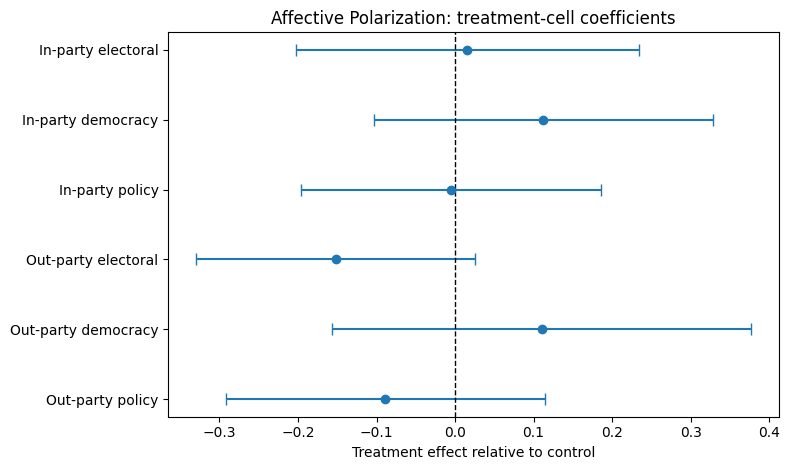

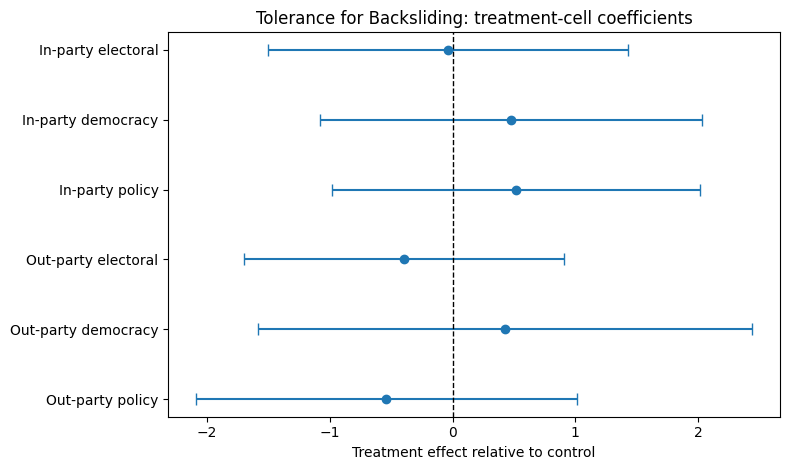

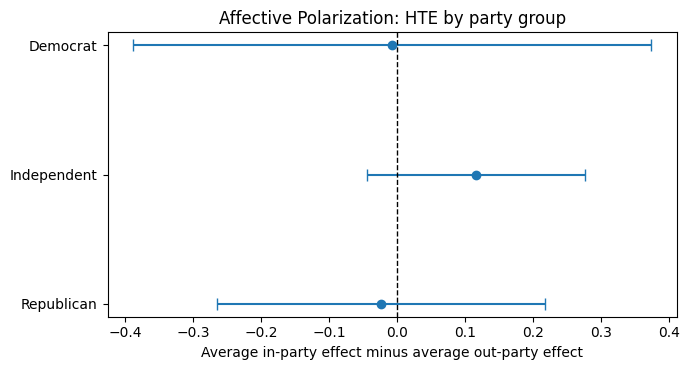

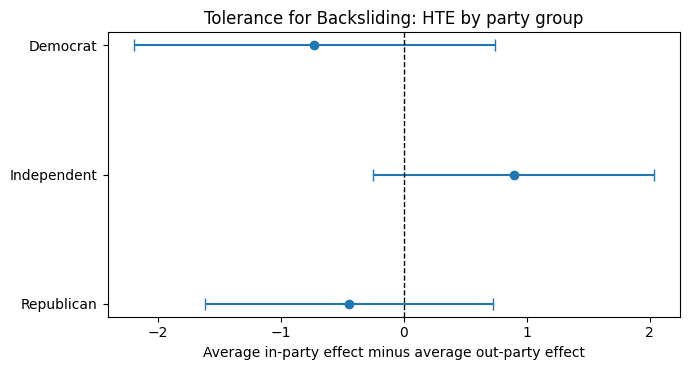

(<Figure size 700x380 with 1 Axes>,
 <Axes: title={'center': 'Tolerance for Backsliding: HTE by party group'}, xlabel='Average in-party effect minus average out-party effect'>)

In [57]:

  results = DATA_ANALYSIS()
  #results.print_summary_single("AP")
  results.print_summary_all()

  results.print_f_tests_all()
  results.print_hte_tests_all()

  results.graph_delta_ap()
  results.graph_delta_tb()
  results.plot_hte_in_vs_out('AP')
  results.plot_hte_in_vs_out('TB')




### Executing the Analysis
This cell instantiates the `DATA_ANALYSIS` class, triggering the data processing, model fitting, and statistical tests. It then prints summary tables for the OLS models, F-test results, and HTE results. Finally, it generates and displays plots visualizing the treatment effects on Affective Polarization and Tolerance for Backsliding, as well as HTE by party group.

In [55]:
results.print_f_tests_all()

RQ1: Any treatment (AP) <F test: F=0.0003385383141700302, p=0.9853614084389783, df_denom=89, df_num=1>
RQ1: Any treatment (TB) <F test: F=0.01617216722600125, p=0.8990928612768854, df_denom=89, df_num=1>
RQ2: In vs Out party (AP) <F test: F=1.288463286899484, p=0.2593790891737194, df_denom=89, df_num=1>
RQ2: In vs Out party (TB) <F test: F=0.9493033905211404, p=0.3325374488703394, df_denom=89, df_num=1>
RQ3: Electoral vs Policy (AP) <F test: F=0.06949389222956065, p=0.7926844988914453, df_denom=89, df_num=1>
RQ3: Electoral vs Policy (TB) <F test: F=0.1637485040697852, p=0.6866994491487108, df_denom=89, df_num=1>
RQ3: Democracy vs Policy (AP) <F test: F=2.79128003262014, p=0.09829165435487815, df_denom=89, df_num=1>
RQ3: Democracy vs Policy (TB) <F test: F=0.4755823897081343, p=0.49222436852300755, df_denom=89, df_num=1>
RQ3: Electoral vs Democracy (AP) <F test: F=3.4457803572023415, p=0.06672226790180913, df_denom=89, df_num=1>
RQ3: Electoral vs Democracy (TB) <F test: F=1.126687659059

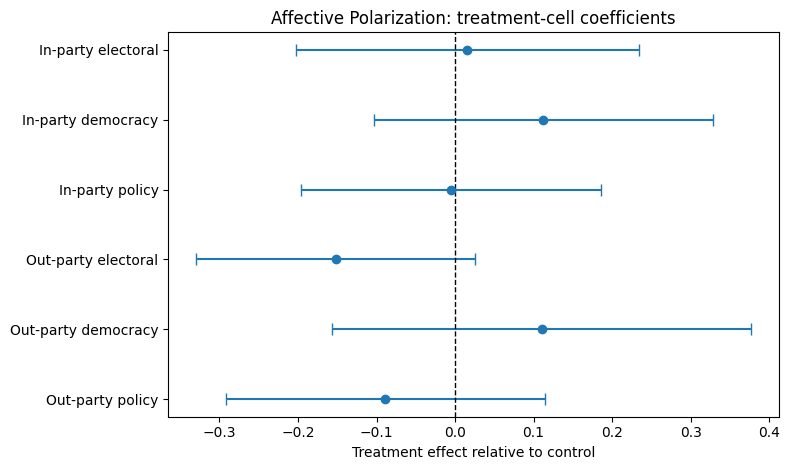

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Affective Polarization: treatment-cell coefficients'}, xlabel='Treatment effect relative to control'>)

In [56]:
results.graph_delta_ap()